In [17]:
import torch 
import torch.nn as nn
from torch_geometric.nn import GATConv, GINConv, global_mean_pool, global_add_pool, global_max_pool
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

class GAT(nn.Module):
    # captures connectivity importances
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim)
        self.conv3 = GATConv(hidden_dim, out_channels)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = nn.GELU()(x)
        x = nn.Dropout(0.3)(x)  # Dropout for regularization
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = nn.GELU()(x)
        x = nn.Dropout(0.3)(x)  # Dropout for regularization
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = nn.GELU()(x)
        return x
    
class GIN(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim):
        super(GIN, self).__init__()

        # MLP for first GIN layer
        self.mlp1 = nn.Sequential(
            nn.Linear(in_channels, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim*2, hidden_dim)
        )

        # MLP for second GIN layer
        self.mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim*2, hidden_dim)
        )

        self.conv1 = GINConv(self.mlp1)
        self.conv2 = GINConv(self.mlp2)
        self.out_lin = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = nn.GELU()(x)
        x = nn.Dropout(0.2)(x)

        x = self.conv2(x, edge_index)
        x = nn.GELU()(x)
        x = self.out_lin(x)
        return x
    
class GatedFusion(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(out_channels, 1),   # score per branch
        )

    def forward(self, x):
        # x: [batch_size, num_branches, out_channels]
        scores = self.gate(x).squeeze(-1)          # [batch_size, num_branches]
        weights = torch.softmax(scores, dim=-1)    # normalize across branches
        out = torch.sum(weights.unsqueeze(-1) * x, dim=1)  # [batch_size, out_channels]
        return out

class ResidualBlock(nn.Module):
    def __init__(self, dim, hidden_dim=None, dropout=0.3):
        super().__init__()
        hidden_dim = hidden_dim or dim
        self.fc = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.fc(x)



class chemberta_net(nn.Module):
    def __init__(self, in_channels_cls, in_channels_mean, out_channels, hidden_dim=128):
        super().__init__()

        # cls branch
        self.cls_proj = nn.Linear(in_channels_cls, hidden_dim)
        self.cls_res = ResidualBlock(hidden_dim)

        # mean branch
        self.mean_proj = nn.Linear(in_channels_mean, hidden_dim)
        self.mean_res = ResidualBlock(hidden_dim)

        # final
        self.fusion = nn.Linear(hidden_dim*2, hidden_dim)
        self.res_final = ResidualBlock(hidden_dim)
        self.out = nn.Linear(hidden_dim, out_channels)

    def forward(self, cls_input, mean_input):
        cls_out = self.cls_res(self.cls_proj(cls_input))
        mean_out = self.mean_res(self.mean_proj(mean_input))
        combined = torch.cat([cls_out, mean_out], dim=1)
        fused = self.fusion(combined)
        fused = self.res_final(fused)
        return self.out(fused)



class smi_ted_net(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim=128):
        super().__init__()
        self.proj_in = nn.Linear(in_channels, hidden_dim*2)   # first projection
        self.res1 = ResidualBlock(hidden_dim*2)
        self.res2 = ResidualBlock(hidden_dim*2)
        self.down = nn.Linear(hidden_dim*2, hidden_dim)       # dimension change
        self.res3 = ResidualBlock(hidden_dim)
        self.out = nn.Linear(hidden_dim, out_channels)

    def forward(self, x):
        x = self.proj_in(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.down(x)
        x = self.res3(x)
        return self.out(x)



class AllAtOnce(nn.Module):

    def __init__(self, in_channels, out_channels, in_channels_cls, in_channels_mean, smi_ted_dim, hidden_dim):
        super(AllAtOnce, self).__init__()
        self.gat = GAT(in_channels, out_channels, hidden_dim)
        self.gin = GIN(in_channels, hidden_dim=hidden_dim, out_dim=out_channels)
        self.chemberta_net = chemberta_net(in_channels_cls, in_channels_mean, out_channels, hidden_dim)
        self.smi_ted_net = smi_ted_net(smi_ted_dim, out_channels, hidden_dim)

        self.pooling_fc = nn.Sequential(
            nn.Linear(out_channels * 6, out_channels),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.branch_fusion = GatedFusion(out_channels)

        self.final_mlp = nn.Sequential(
            nn.Linear(out_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, 1)
        )

    def forward(self, graph_data, cls_embed, mean_embed, smi_ted):
        # Graph data
        x, edge_index, batch = graph_data.x, graph_data.edge_index, graph_data.batch

        # mfnet_out = self.mfnet(x, edge_index)
        gat_out = self.gat(x, edge_index)
        gin_out = self.gin(x, edge_index)

        # Pooling
        gat_max = global_max_pool(gat_out, batch)
        gin_max = global_max_pool(gin_out, batch)
        gat_add = global_add_pool(gat_out, batch)
        gin_add = global_add_pool(gin_out, batch)
        gat_mean = global_mean_pool(gat_out, batch)
        gin_mean = global_mean_pool(gin_out, batch)

        # Concatenate all pooled features
        pooled = torch.cat([gat_max, gin_max, gat_add, gin_add, gat_mean, gin_mean], dim=1)
        pool_out = self.pooling_fc(pooled)

        chemberta_out = self.chemberta_net(cls_embed, mean_embed)
        smi_out = self.smi_ted_net(smi_ted)
        # Stack branch outputs shape [batch_size, num_branches, out_channels] for attention
        stacked = torch.stack([
            pool_out,
            chemberta_out,
            smi_out
        ], dim=1)

        out = self.branch_fusion(stacked)

        # Final prediction head
        out = self.final_mlp(out)
        return out
    
if __name__ == "__main__":
    # Example usage
    model = AllAtOnce(in_channels=10, out_channels=32, in_channels_cls=600, in_channels_mean=600, hidden_dim=64, smi_ted_dim=768)
    print(model)
    print("Model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

AllAtOnce(
  (gat): GAT(
    (conv1): GATConv(10, 64, heads=1)
    (conv2): GATConv(64, 64, heads=1)
    (conv3): GATConv(64, 32, heads=1)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (gin): GIN(
    (mlp1): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
    )
    (mlp2): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inpl

In [18]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
from rdkit import Chem
from torch.utils.data import random_split

class SMI_CB_Graph_Dataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)
    
    def mol_to_graph(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")

        edge_index = []
        node_features = []
        edge_features = []

        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()

            bond_type = bond.GetBondTypeAsDouble()  # 1.0, 2.0, 3.0, 1.5 (aromatic)
            is_conjugated = bond.GetIsConjugated()
            is_in_ring = bond.IsInRing()

            edge_feat = [bond_type, float(is_conjugated), float(is_in_ring)]

            # Add both directions
            edge_index.append((i, j))
            edge_index.append((j, i))
            edge_features.append(edge_feat)
            edge_features.append(edge_feat)

        # one hot encoding of atom types
        for atom in mol.GetAtoms():
            atom_type = atom.GetAtomicNum()
            aromatic = atom.GetIsAromatic()
            formal_charge = atom.GetFormalCharge()
            hybridization = int(atom.GetHybridization())
            degree = atom.GetDegree()
            valence = atom.GetTotalValence()

            node_features.append([atom_type, aromatic, formal_charge, hybridization, degree, valence])  

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
        x = torch.tensor(node_features, dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # fetch graph data
        smiles = row['Canonical SMILES']
        graph_data = self.mol_to_graph(smiles)

        # Get cls and mean embeddings
        cls_embedding = row['X_cls']
        mean_embedding = row['X_mean']

        cls_embedding = torch.tensor(cls_embedding, dtype=torch.float)
        mean_embedding = torch.tensor(mean_embedding, dtype=torch.float)
        smi_ted_embedding = np.array(row['X_smi_ted'], dtype=np.float32)
        smi_ted_embedding = torch.tensor(smi_ted_embedding, dtype=torch.float)

        # Get labels 
        label = torch.tensor(row['target'], dtype=torch.float)

        return graph_data, cls_embedding, mean_embedding, smi_ted_embedding, label

def main():
    dataset_path = "./ct.parquet"
    df = pd.read_parquet(dataset_path)

    df['X_cls'] = df['X_cls'].apply(lambda x: np.array(x))
    df['X_mean'] = df['X_mean'].apply(lambda x: np.array(x))

    # Create dataset
    dataset = SMI_CB_Graph_Dataset(df)
    print("node feature dims", dataset[0][0].x.shape[1])
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # sample one datapoint from dataset and print node feat dims
    for graph_data, cls_embed, mean_embed, smi_ted_embed, labels in dataloader:
        print(f"Graph data: {graph_data}")
        print(f"CLS embedding shape: {cls_embed.shape}")
        print(f"Mean embedding shape: {mean_embed.shape}")
        print(f"SMI-TED embedding shape: {smi_ted_embed.shape}")
        print(f"Labels shape: {labels.shape}")
        break

if __name__ == "__main__":
    main()

node feature dims 6
Graph data: DataBatch(x=[1005, 6], edge_index=[2, 2008], edge_attr=[2008, 3], batch=[1005], ptr=[33])
CLS embedding shape: torch.Size([32, 600])
Mean embedding shape: torch.Size([32, 600])
SMI-TED embedding shape: torch.Size([32, 768])
Labels shape: torch.Size([32])


Dataset loaded

Input channels: 768, Input Channels ChemBERTa: 600, 600
Output channels: 128
Loaders created. Starting training...

Model parameters: 1117698
epoch: 0, train loss: 0.633, val loss: 0.341
epoch: 1, train loss: 0.394, val loss: 0.282
epoch: 2, train loss: 0.342, val loss: 0.284
epoch: 3, train loss: 0.308, val loss: 0.241
epoch: 4, train loss: 0.283, val loss: 0.235
epoch: 5, train loss: 0.271, val loss: 0.237
epoch: 6, train loss: 0.258, val loss: 0.242
epoch: 7, train loss: 0.248, val loss: 0.222
epoch: 8, train loss: 0.253, val loss: 0.224
epoch: 9, train loss: 0.240, val loss: 0.224
epoch: 10, train loss: 0.233, val loss: 0.220
epoch: 11, train loss: 0.239, val loss: 0.251
epoch: 12, train loss: 0.231, val loss: 0.236
epoch: 13, train loss: 0.226, val loss: 0.217
epoch: 14, train loss: 0.211, val loss: 0.230
epoch: 15, train loss: 0.220, val loss: 0.236
epoch: 16, train loss: 0.216, val loss: 0.226
epoch: 17, train loss: 0.211, val loss: 0.216
epoch: 18, train loss: 0

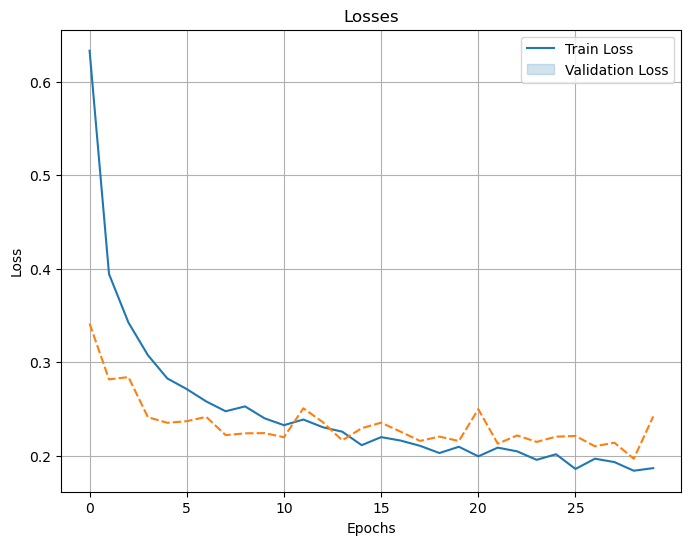

In [19]:
def iterate(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for graph_data, embed_cls, embed_mean, smi_ted, labels in train_loader:
        smi_ted = smi_ted.to(device)
        embed_cls = embed_cls.to(device)
        embed_mean = embed_mean.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(graph_data, embed_cls, embed_mean, smi_ted)
        loss = criterion(outputs.view(-1), labels.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for graph_data, embed_cls, embed_mean, smi_ted, labels in val_loader:
            graph_data = graph_data.to(device)
            embed_cls = embed_cls.to(device)
            embed_mean = embed_mean.to(device)
            smi_ted = smi_ted.to(device)
            labels = labels.to(device)

            outputs = model(graph_data, embed_cls, embed_mean, smi_ted)
            loss = criterion(outputs.view(-1), labels.view(-1))
            total_loss += loss.item()

    return total_loss / len(val_loader)

def evaluate_regression(y_true, y_pred):
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()

    y_true = np.array(y_true, dtype=float).flatten()
    y_pred = np.array(y_pred, dtype=float).flatten()

    if np.any(np.isnan(y_true)) or np.any(np.isnan(y_pred)):
        raise ValueError("NaNs detected in y_true or y_pred!")
    if np.any(np.isinf(y_true)) or np.any(np.isinf(y_pred)):
        raise ValueError("Infs detected in y_true or y_pred!")
    assert y_true.shape == y_pred.shape, f"Shape mismatch: {y_true.shape} vs {y_pred.shape}"

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    spearman_r, _ = spearmanr(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Pearson r: {pearson_r:.4f}")
    print(f"Spearman rho: {spearman_r:.4f}")

    return f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\nPearson r: {pearson_r:.4f}\nSpearman rho: {spearman_r:.4f}"

def make_plots(y_true, y_pred, run_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', lw=2)  # Line y=x
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Predictions vs True Values")
    plt.savefig(f"results/predictions_{run_name}.png")
    plt.close()

    plt.figure(figsize=(8, 6))
    residuals = y_true.flatten() - y_pred.flatten()
    plt.scatter(y_pred.flatten(), residuals)
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Residuals vs Predicted Values")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.savefig(f"results/residuals_{run_name}.png")
    plt.close()

def main():
    results_path = "./results"
    model_dir = "./models"

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(results_path, exist_ok=True)
    dataset_path = "./ct.parquet"
    ct = pd.read_parquet(dataset_path)
    print("Dataset loaded\n")

    ct['X_smi_ted'] = ct['X_smi_ted'].apply(lambda x: np.array(x))

    # Create dataset
    dataset = SMI_CB_Graph_Dataset(ct)

    # dataset used:
    df = ct
    run_name = "ct_AAO"

    # split the dataset
    train, test, val = random_split(
        dataset, 
        lengths=[0.75, 0.15, 0.1],
        generator=torch.Generator().manual_seed(42)
    )

    trainLoader = DataLoader(train, batch_size=32, shuffle=True)
    testLoader = DataLoader(test, batch_size=32, shuffle=False)
    valLoader = DataLoader(val, batch_size=32, shuffle=False)

    in_channels = dataset[0][0].x.shape[1]
    in_channels_cls = df['X_cls'].iloc[0].shape[0]
    in_channels_mean = df['X_mean'].iloc[0].shape[0]
    smi_ted_dim = df['X_smi_ted'].iloc[0].shape[0]

    # ---------
    out_channels = 128
    hidden_dim = 128
    # ---------

    print(f"Input channels: {smi_ted_dim}, Input Channels ChemBERTa: {in_channels_cls}, {in_channels_mean}")
    print(f"Output channels: {out_channels}")

    def train_model(trainLoader, valLoader, in_channels, in_channels_cls, in_channels_mean, smi_ted_dim, out_channels, hidden_dim,
                epochs=30, patience=10):

        print("Loaders created. Starting training...\n")
        model = AllAtOnce(
            smi_ted_dim=smi_ted_dim,
            in_channels=in_channels,
            in_channels_cls=in_channels_cls,
            in_channels_mean=in_channels_mean,
            out_channels=out_channels,
            hidden_dim=hidden_dim
        )
        print("Model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = torch.nn.MSELoss()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
        history = []

        for epoch in range(epochs):
            train_loss = iterate(model, trainLoader, optimizer, criterion, device)
            val_loss = evaluate(model, valLoader, criterion, device)

            losses = {
                'train_loss': train_loss,
                'val_loss': val_loss
            }
            history.append(losses)

            print(f"epoch: {epoch}, train loss: {train_loss:.3f}, val loss: {val_loss:.3f}")

            # --- early stopping check ---
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.3f}")
                    break

        # restore best weights
        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        print("Training Complete")

        # plot losses
        losses_df = pd.DataFrame(history)
        plt.figure(figsize=(8, 6))
        plt.title("Losses")
        sns.lineplot(data=losses_df)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend(['Train Loss', 'Validation Loss'])
        plt.xticks(range(0, epochs, 5))
        plt.grid()
        plt.savefig(f"results/losses_{run_name}.png")

        return history, model

    history, model = train_model(
        trainLoader=trainLoader, 
        valLoader=valLoader, 
        in_channels=in_channels, 
        in_channels_cls=in_channels_cls, 
        in_channels_mean=in_channels_mean, 
        smi_ted_dim=smi_ted_dim, 
        out_channels=out_channels, 
        hidden_dim=hidden_dim
    )

    # test the model on the test data:

    criterion = torch.nn.MSELoss()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    test_loss = evaluate(model, testLoader, criterion, device)
    print(f'Test loss: {test_loss}')
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for graph_data, embed_cls, embed_mean, smi_ted, labels in testLoader:
            graph_data = graph_data.to(device)
            embed_cls = embed_cls.to(device)
            embed_mean = embed_mean.to(device)
            smi_ted = smi_ted.to(device)
            labels = labels.to(device)

            outputs = model(graph_data, embed_cls, embed_mean, smi_ted)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    print("Evaluation metrics:")
    output = evaluate_regression(y_true, y_pred)
    with open(f"results/perf_mets_{run_name}.txt", 'w+') as f:
        f.write(output)

    make_plots(y_true, y_pred, run_name)
    print("Plots saved as predictions.png and residuals.png")

    # Save the model
    torch.save(model.state_dict(), f"models/model_{run_name}.pth")
    print(f"Model saved as models/model_{run_name}.pth")

if __name__ == '__main__':
    main()

